In [31]:
import scipy as sp
from scipy.misc import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones
import torch
from numpy import pi, log

In [32]:
def hl2_prime(n, z):
    return (n / z) * hankel2(n, z) - hankel2(n + 1, z) # derivative for hankel function of second kind
def hl1_prime(n, z):
    return (n / z) * hankel1(n, z) - hankel1(n + 1, z) # derivative for hankel function of first kind
def hl1_asymptotic(n, z):
    #return sqrt(2/(pi*z))*np.exp(1j*(z-pi/4))*(-1j)**n
    return sqrt(1/(pi*z))*(1-1j)*np.exp(1j*z)*(-1j)**n
def hl2_asymptotic(n, z):
    return np.conj(hl1_asymptotic(n, z))

### We plot the surface plasmon dispersion (with and without radiative corrections) for a graphene coating at Fermi energy 0.4 eV

In [33]:
#Rs = np.linspace(2, 256, 255) # Radii in nanometers
Rs = np.linspace(2, 1024, 1023)
epsilon_F = 0.4 # Fermi energy
alpha = 1/137 # Fine structure constant
epsilon_1 = 1
epsilon_2 = 1 # Dielectric constants of the cylinder and the environment, respectively

In [34]:
quasistatic_dispersions = zeros((5, (len(Rs)))) # For the first five angular momenta 
for (i, l) in enumerate(range(1, 6)):
    quasistatic_dispersions[i, :] = sqrt(l*alpha*800/(epsilon_1+epsilon_2)/(epsilon_F*Rs)); #Intraband only approximation

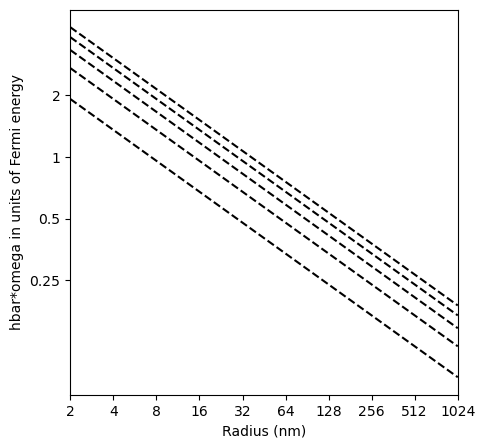

In [35]:
fig, ax = plt.subplots(figsize=(5, 5))
for i in range(0, 5):
    ax.plot(log(Rs), log(quasistatic_dispersions[i, :]), color="black", linestyle="dashed" )
plt.gca().set_xlim(log(2), log(1024))
plt.gca().set_xticks(log([2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]), [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]);
plt.gca().set_yticks(log([0.25, 0.5, 1, 2]), [0.25, 0.5, 1, 2]);
plt.gca().set_xlabel("Radius (nm)");
plt.gca().set_ylabel("hbar*omega in units of Fermi energy");

In [36]:
M = 1000
hbar_omegas_radiative = linspace(0.001, epsilon_F*5, M)
hbar_omegas_radiative_reshaped = hbar_omegas_radiative.reshape((M, 1)).repeat(len(Rs), 1)
Rs_radiative_reshaped = Rs.reshape((1, len(Rs))).repeat(M, 0)

radiative_dispersions =  zeros((5, (len(Rs))))

x0 = Rs_radiative_reshaped*hbar_omegas_radiative_reshaped/200
x2 = x0*sqrt(epsilon_2) # nkx outside the cylinder 
x1 = x0*sqrt(epsilon_1) # nkx in the cylinder 
sigma = 4j*alpha*epsilon_F/(hbar_omegas_radiative_reshaped)

for (i, l) in enumerate(range(1, 6)):    
    tm_denominator = jvp(l, x1, 1) * hankel1(l, x2) - sqrt(epsilon_1) * jv(l, x1) * hl1_prime(l, x2) - 1j*sigma*jvp(l, x1, 1)*hl1_prime(l, x2) 
    radiative_dispersions[i, :] = hbar_omegas_radiative[log(np.abs(tm_denominator)).argmin(axis=0)]/epsilon_F

In [37]:
hbar = 6.67*1e-16 # Planck constant in eV*seconds
c = 3*1e17 # speed of light in nanometers per second

kR_quasistatic = (Rs*radiative_dispersions)*epsilon_F/(hbar*c)
kR_radiative = (Rs*quasistatic_dispersions)*epsilon_F/(hbar*c)

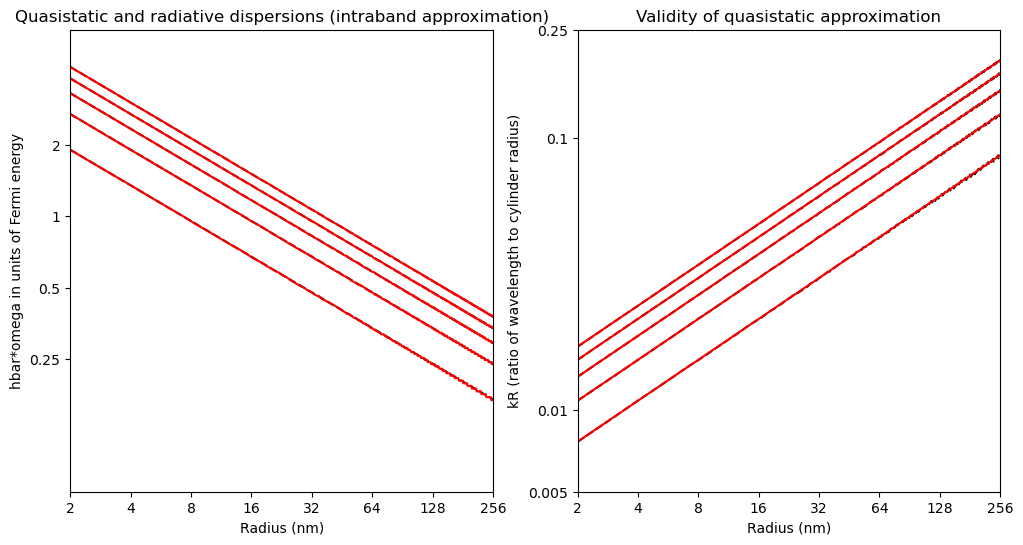

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
for i in range(0, 5):
    ax1.plot(log(Rs), log(quasistatic_dispersions[i, :]), color="black", linestyle="dashed", label=f"Quasistatic limit, l={i+1}")
    ax1.plot(log(Rs), log(radiative_dispersions[i, :]), color="red", linestyle="solid", label=f"With radiative corrections, l={i+1}")
    ax2.plot(log(Rs), log(kR_quasistatic[i, :]), color="black", linestyle="dashed", label=f"Quasistatic limit, l={i+1}")
    ax2.plot(log(Rs), log(kR_radiative[i, :]), color="red", linestyle="solid", label=f"With radiative corrections, l={i+1}")

ax1.set_xlim(log(2), log(256))
ax1.set_xticks(log([2, 4, 8, 16, 32, 64, 128, 256]), [2, 4, 8, 16, 32, 64, 128, 256]);
ax1.set_yticks(log([0.25, 0.5, 1, 2]), [0.25, 0.5, 1, 2]);
#gca().legend()
ax1.set_xlabel("Radius (nm)");
ax1.set_ylabel("hbar*omega in units of Fermi energy");
ax1.set_title("Quasistatic and radiative dispersions (intraband approximation)")

ax2.set_xlim(log(2), log(256))
ax2.set_xticks(log([2, 4, 8, 16, 32, 64, 128, 256]), [2, 4, 8, 16, 32, 64, 128, 256]);
ax2.set_yticks(log([0.005, 0.01, 0.1, 0.25]), [0.005, 0.01, 0.1, 0.25]);
ax2.set_ylim(log(0.005), log(0.25));
ax2.set_xlabel("Radius (nm)");
ax2.set_ylabel("kR (ratio of wavelength to cylinder radius)");
ax2.set_title("Validity of quasistatic approximation");


### In the below, we reintroduce the interband contribution (and compare between quasistatic and fully radiative solutions as above)

In [43]:
M = 1000
N = 1000
R_range = np.linspace(2, 256, M)
hbar_omega_range = epsilon_F * np.linspace(0.01, 1.999, N)
quasistatic_interband_dispersions = zeros((5, M))

for (i, l) in enumerate(range(1, 6)):
    lhs = R_range*(epsilon_1+epsilon_2)/l
    rhs = (800 * alpha)/(hbar_omega_range)*(epsilon_F/hbar_omega_range+(1/4)*log(abs((2*epsilon_F-hbar_omega_range)/(2*epsilon_F+hbar_omega_range))))
    quasistatic_interband_dispersions[i, :] = hbar_omega_range[np.argmin(log(abs(lhs.reshape(M, 1 ).repeat(N, 1) - rhs.reshape(1, N).repeat(M, 0))), 1)]/epsilon_F

In [44]:
M = 1000
hbar_omegas_radiative = linspace(0.01, epsilon_F*1.6, M)
hbar_omegas_radiative_reshaped = hbar_omegas_radiative.reshape((M, 1)).repeat(len(R_range), 1)
Rs_radiative_reshaped = R_range.reshape((1, len(R_range))).repeat(M, 0)

radiative_interband_dispersions =  zeros((5, (len(R_range))))

x0 = Rs_radiative_reshaped*hbar_omegas_radiative_reshaped/200
x2 = x0*sqrt(epsilon_2) # nkx outside the cylinder 
x1 = x0*sqrt(epsilon_1) # nkx in the cylinder 
sigma = 4j*alpha*(epsilon_F/(hbar_omegas_radiative_reshaped)+(1/4)*log(abs((2*epsilon_F-hbar_omegas_radiative_reshaped )/(2*epsilon_F+hbar_omegas_radiative_reshaped ))) )

for (i, l) in enumerate(range(1, 6)):    
    tm_denominator = jvp(l, x1, 1) * hankel1(l, x2) - sqrt(epsilon_1) * jv(l, x1) * hl1_prime(l, x2) - 1j*sigma*jvp(l, x1, 1)*hl1_prime(l, x2) 
    radiative_interband_dispersions[i, :] = hbar_omegas_radiative[log(np.abs(tm_denominator)).argmin(axis=0)]/epsilon_F

In [42]:
kR_quasistatic_interband = (R_range*radiative_interband_dispersions)*epsilon_F/(hbar*c)
kR_radiative_interband = (R_range*quasistatic_interband_dispersions)*epsilon_F/(hbar*c)

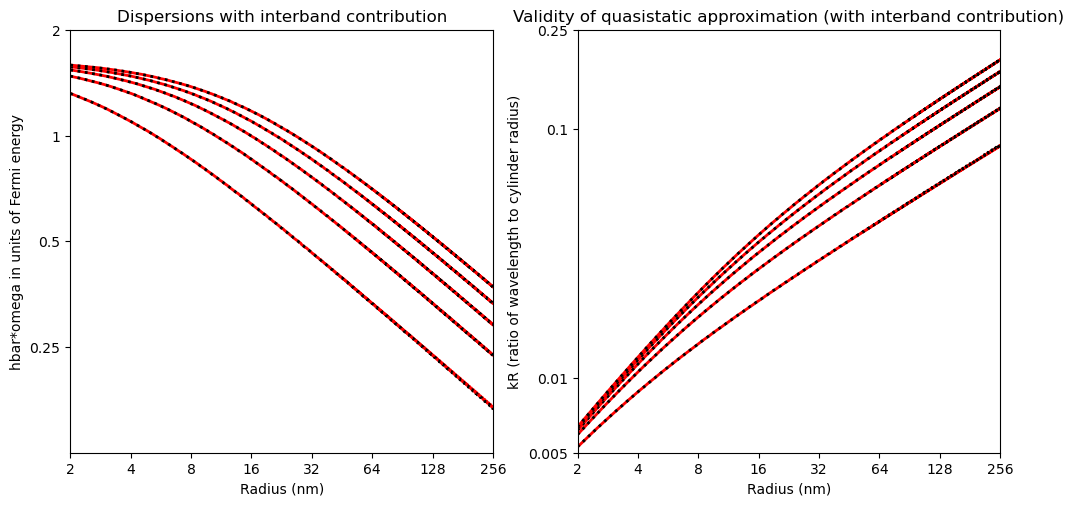

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
for i in range(0, 5): 
    ax1.plot(log(R_range), log(quasistatic_interband_dispersions[i, :]), color="red", linewidth=2)
    ax1.plot(log(R_range), log(radiative_interband_dispersions[i, :]), linestyle="dotted", color="black", linewidth=2)

    ax2.plot(log(R_range), log(kR_quasistatic_interband[i, :]), color="red", linewidth=2)
    ax2.plot(log(R_range), log(kR_radiative_interband[i, :]), linestyle="dotted", color="black", linewidth=2)

ax1.set_xlim(log(2), log(256))
ax1.set_ylim(log(0.125), log(2))

ax1.set_xticks(log([2, 4, 8, 16, 32, 64, 128, 256]), [2, 4, 8, 16, 32, 64, 128, 256]);
ax1.set_yticks(log([0.25, 0.5, 1, 2]), [0.25, 0.5, 1, 2]);
ax1.set_aspect((log(256)-log(2))/(log(2)-log(0.125)))
ax1.set_xlabel("Radius (nm)");
ax1.set_ylabel("hbar*omega in units of Fermi energy");
ax1.set_title("Dispersions with interband contribution")

ax2.set_xlim(log(2), log(256))
ax2.set_xticks(log([2, 4, 8, 16, 32, 64, 128, 256]), [2, 4, 8, 16, 32, 64, 128, 256]);
ax2.set_yticks(log([0.005, 0.01, 0.1, 0.25]), [0.005, 0.01, 0.1, 0.25]);
ax2.set_ylim(log(0.005), log(0.25));
ax2.set_aspect((log(256)-log(2))/(log(0.25)-log(0.005)))
ax2.set_xlabel("Radius (nm)");
ax2.set_ylabel("kR (ratio of wavelength to cylinder radius)");
ax2.set_title("Validity of quasistatic approximation (with interband contribution)");